### **Import Library** ###

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

### **Import Data** ###

In [14]:
data = yf.download("GOOGL", start="2018-01-01", end="2024-12-31")

# Ambil variabel (multivariat untuk VAR)
data = data[['Close', 'Volume']]

# Hapus missing value
data = data.dropna()

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price           Close    Volume
Ticker          GOOGL     GOOGL
Date                           
2018-01-02  53.220631  31766000
2018-01-03  54.128632  31318000
2018-01-04  54.338886  26052000
2018-01-05  55.059433  30250000
2018-01-08  55.253822  24644000


In [26]:
# Cek apakah ada missing value
missing_values = data.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing_values)


Jumlah missing values per kolom:
Close     0
Volume    0
dtype: int64


In [27]:
# Cek apakah ada nilai NaN
nan_values = data.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_values)


Jumlah nilai NaN per kolom:
Close     0
Volume    0
dtype: int64


### **Visualisasi Awal** ###

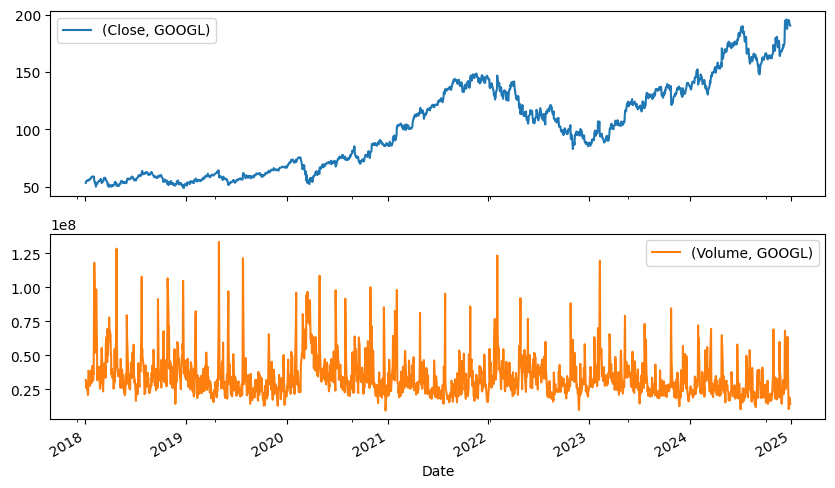

In [15]:
data.plot(subplots=True, figsize=(10,6))
plt.show()

### **Uji Stasioneritas (ADF Test)** ###

In [28]:
from statsmodels.tsa.stattools import adfuller

# Uji ADF
result = adfuller(data['Close'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

# Cek Hipotesis
if result[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")


ADF Statistic: 0.039119
p-value: 0.961650
Data tidak stasioner, lakukan differencing.


**Hasil pengujian menunjukkan bahwa data belum stabil (tidak stasioner), artinya pola data masih berubah-ubah sehingga belum bisa langsung digunakan untuk pemodelan.**

### **Melakukan Differencing** ###

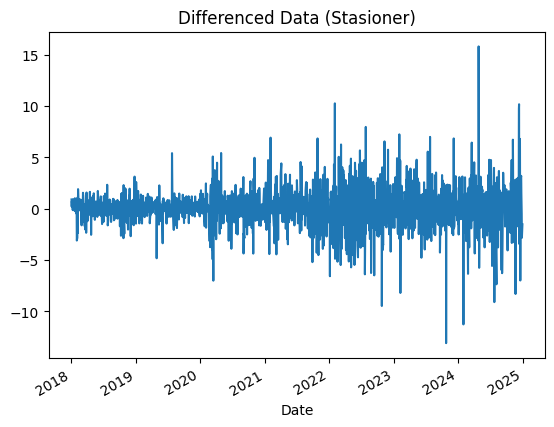

p-value after differencing: 0.000000
Data stasioner, lanjutkan analisis.


In [29]:
# Lakukan Differencing jika data tidak stasioner
data_diff = data['Close'].diff().dropna()
data_diff.plot(title="Differenced Data (Stasioner)")
plt.show()

# Uji ADF lagi setelah differencing
result_diff = adfuller(data_diff)
print('p-value after differencing: %f' % result_diff[1])

# Cek Hipotesis
if result_diff[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")


**Setelah dilakukan differencing (menghitung perubahan antar waktu), data menjadi lebih stabil. Ini berarti data sudah memenuhi syarat untuk dilakukan analisis lebih lanjut.**

In [30]:
# Cek apakah ada missing value
missing_values = data_diff.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing_values)

# Cek apakah ada nilai NaN
nan_values = data_diff.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_values)


Jumlah missing values per kolom:
0
Jumlah nilai NaN per kolom:
0


### **Cek Autocorrelation (ACF) dan Partial Autocorrelation (PACF)** ###

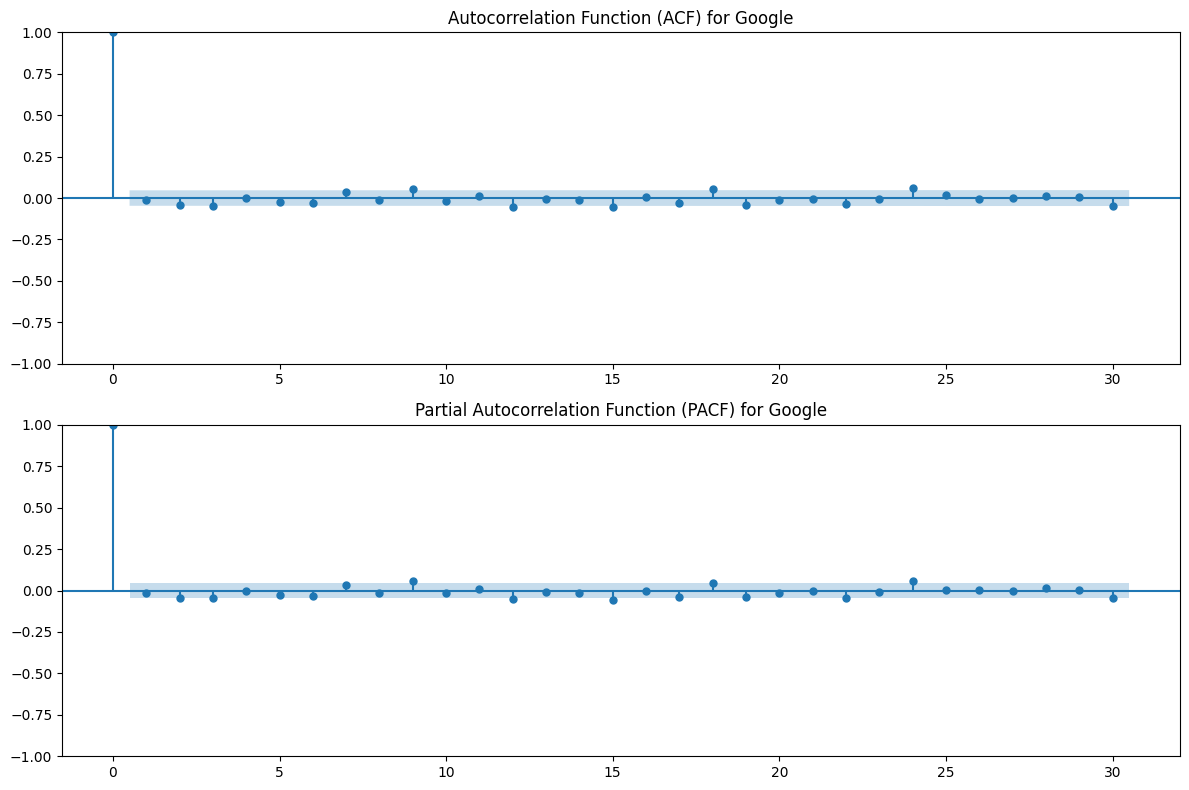

In [47]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF dan PACF
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# ACF untuk menentukan q
plot_acf(data_diff, lags=30, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF) for Google')

# PACF untuk menentukan p
plot_pacf(data_diff, lags=30, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF) for Google')

plt.tight_layout()
plt.show()


ACF (Autocorrelation Function) dan PACF (Partial Autocorrelation Function) adalah dua alat penting dalam analisis time series, khususnya untuk memilih urutan dalam model ARIMA (AutoRegressive Integrated Moving Average).

ACF membantu dalam menentukan urutan MA (
𝑞) dari model ARIMA, yang menunjukkan korelasi antara nilai sekarang dan lag (nilai masa lalu).
PACF digunakan untuk menentukan urutan AR (
𝑝
) dari model ARIMA, yang menunjukkan korelasi antara nilai sekarang dan nilai masa lalu, dengan menghilangkan pengaruh lag perantara.
Secara umum:

AR (Autoregressive) 
𝑝
: Nilai 
𝑝
 adalah jumlah lag signifikan pertama pada PACF plot sebelum nilai PACF menurun secara cepat.
MA (Moving Average) 
𝑞
: Nilai 
𝑞
 adalah jumlah lag signifikan pertama pada ACF plot sebelum nilai ACF menurun secara cepat.


**Grafik ACF dan PACF digunakan untuk melihat hubungan data dengan nilai sebelumnya. Dari grafik ini dipilih model ARIMA dengan parameter (1,1,1), yang berarti data dipengaruhi oleh nilai sebelumnya dan kesalahan di masa lalu.** 

### **Model ARIMA** ###

In [34]:
model = ARIMA(data['Close'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1760
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3723.912
Date:                Sat, 11 Apr 2026   AIC                           7453.824
Time:                        22:53:10   BIC                           7470.241
Sample:                             0   HQIC                          7459.891
                               - 1760                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8147      0.112      7.274      0.000       0.595       1.034
ma.L1         -0.8457      0.104     -8.158      0.000      -1.049      -0.643
sigma2         4.0400      0.067     60.160      0.0

c:\Users\Marcella\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Marcella\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Marcella\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Marcella\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-statio

**Model ARIMA menunjukkan bahwa pergerakan harga saham saat ini dipengaruhi oleh pergerakan sebelumnya. Model ini dapat digunakan untuk memahami pola dan membuat prediksi.**

### **Forecasting** ###

In [37]:
forecast = model_fit.forecast(steps=10)

print(forecast)



1760    190.346765
1761    190.336031
1762    190.327286
1763    190.320161
1764    190.314356
1765    190.309626
1766    190.305773
1767    190.302634
1768    190.300076
1769    190.297992
Name: predicted_mean, dtype: float64


c:\Users\Marcella\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


**Hasil forecasting menunjukkan perkiraan harga saham untuk beberapa hari ke depan. Garis prediksi mengikuti pola data sebelumnya, namun terdapat area bayangan yang menunjukkan bahwa prediksi tidak sepenuhnya pasti.**

c:\Users\Marcella\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


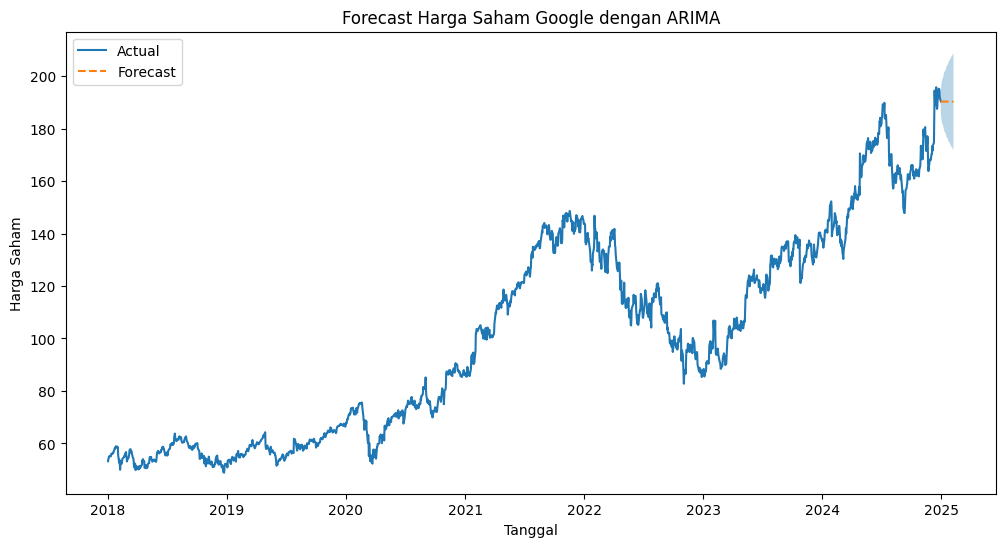

In [40]:
import matplotlib.pyplot as plt

# Forecast + confidence interval
forecast_result = model_fit.get_forecast(steps=30)

forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Index waktu untuk forecast
forecast_index = pd.date_range(start=data.index[-1], periods=30, freq='B')

# Plot
plt.figure(figsize=(12,6))

# Data asli
plt.plot(data.index, data['Close'], label='Actual')

# Forecast
plt.plot(forecast_index, forecast, label='Forecast', linestyle='dashed')

# Confidence interval (area bayangan)
plt.fill_between(forecast_index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 alpha=0.3)

plt.title('Forecast Harga Saham Google dengan ARIMA')
plt.xlabel('Tanggal')
plt.ylabel('Harga Saham')
plt.legend()

plt.show()

**Grafik memperlihatkan perbandingan antara data asli dan hasil prediksi. Terlihat bahwa model cukup mampu mengikuti tren, meskipun semakin jauh ke depan, tingkat ketidakpastian semakin besar.**

### **Impulse Response Function (IRF)** ###

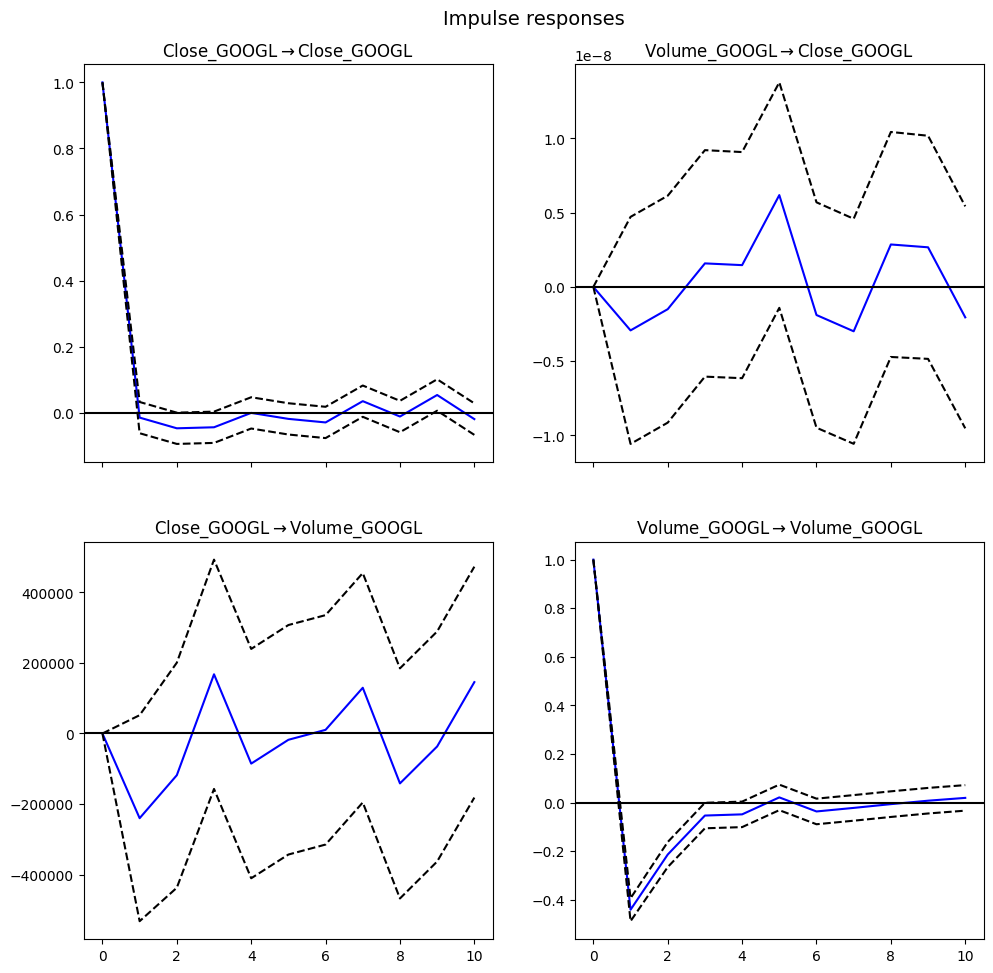

In [20]:
irf = var_model.irf(10)
irf.plot()
plt.show()

**Hasil ini menunjukkan bagaimana perubahan pada satu faktor (misalnya volume transaksi) dapat memengaruhi harga saham dalam beberapa waktu ke depan. Pengaruh tersebut biasanya tidak berlangsung lama.**

### **Granger Causality** ###

In [24]:
# Ambil data
data = yf.download("GOOGL", start="2018-01-01", end="2024-12-31")

# Flatten kolom (INI PENTING 🔥)
data.columns = data.columns.get_level_values(0)

# Pilih variabel
data = data[['Close', 'Volume']]

# Rename biar clean
data.columns = ['Close', 'Volume']

# Differencing
data_diff = data.diff().dropna()

[*********************100%***********************]  1 of 1 completed


In [25]:
model = VAR(data_diff)
lag_order = model.select_order(maxlags=15)
optimal_lag = lag_order.selected_orders['aic']
var_model = model.fit(optimal_lag)

granger_test = var_model.test_causality('Close', ['Volume'], kind='f')
print(granger_test.summary())

Granger causality F-test. H_0: Volume does not Granger-cause Close. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df         
----------------------------------------------------------
        0.5374          1.755   0.892 (12, np.int64(3444))
----------------------------------------------------------


c:\Users\Marcella\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


**Hasil uji Granger menunjukkan bahwa volume transaksi tidak memiliki pengaruh yang signifikan terhadap harga saham. Hal ini ditunjukkan oleh nilai p-value sebesar 0,892 yang lebih besar dari 0,05, sehingga perubahan volume tidak dapat digunakan untuk memprediksi pergerakan harga saham.**

### **Kesimpulan** ###                                      
Berdasarkan analisis data saham Alphabet Inc., diketahui bahwa harga saham memiliki pola dari waktu ke waktu sehingga dapat diprediksi menggunakan model ARIMA. Setelah data dibuat stabil, model mampu menggambarkan tren pergerakan harga dan digunakan untuk melakukan prediksi ke depan.

Namun, hasil uji hubungan antar variabel menunjukkan bahwa volume transaksi tidak memiliki pengaruh yang signifikan terhadap harga saham. Artinya, naik turunnya jumlah transaksi tidak dapat digunakan untuk menjelaskan atau memprediksi perubahan harga saham.